# 1 - Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0].parents[0]))

In [3]:
from src.utils import config, io
from src.preprocessing import preprocess_pipeline
from src.models import model_pipeline, evaluate

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


In [4]:
import mlflow
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

from missingno import matrix as msno_matrix
from missingno import heatmap as msno_heatmap

sns.set_theme(style="whitegrid", context="talk")

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 2 - Preprocessing

In [7]:
def expanding_window_split(df, start_year, end_year, val_start_year):

    for val_year in range(val_start_year, end_year + 1):
        
        train_mask = (df['YEAR'] >= start_year) & (df['YEAR'] < val_year)
        val_mask = df['YEAR'] == val_year
        
        train_idx = df.index[train_mask]
        val_idx = df.index[val_mask]
        
        if len(val_idx) > 0:
            yield train_idx, val_idx


# 3 - Parameter Tuning XGBoost

## 3.1 - Run Parameters Cross Validation

In [ ]:
mlflow.set_tracking_uri(config.PROJECT_ROOT / 'models/mlruns')
# mlflow.create_experiment('XGBoost Classifier Model Parameters')
mlflow.set_experiment('XGBoost Classifier Model Parameters')

<Experiment: artifact_location='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/408821925195767283', creation_time=1771165383489, experiment_id='408821925195767283', last_update_time=1771165383489, lifecycle_stage='active', name='XGBoost Model Parameters', tags={}>

In [11]:
X = io.load_csv(config.PROCESSED_DATA_DIR / 'X.csv', index_col=0)
y = io.load_csv(config.PROCESSED_DATA_DIR / 'y.csv', index_col=0)

In [17]:
from sklearn.preprocessing import LabelEncoder

y_encoder = LabelEncoder()
y_encoder.fit(y)

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LabelEncoder()

In [21]:
preprocessor_params = {
    'num_imputer': 'uni',
    'num_imputer_uni_strategy': 'most_frequent',
    'cat_imputer': 'uni',
    'cat_imputer_uni_strategy': 'most_frequent'
}
preprocessor = preprocess_pipeline.build_preprocessor(X, params=preprocessor_params)

In [ ]:
model_params_grid = {
    'min_child_weight': [1, 2, 3, 5],
    'gamma': [0.0, 0.1, 0.5, 1, 1.5, 2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [4, 6, 8, 10]
}

In [ ]:
i = 0
for min_child_weight, gamma, subsample, colsample_bytree, max_depth in product( # solver, class_weight
    model_params_grid['min_child_weight'],
    model_params_grid['gamma'],
    model_params_grid['subsample'],
    model_params_grid['colsample_bytree'],
    model_params_grid['max_depth']
):

    i += 1
    if i%50 == 0:
        print('Progress', str(round(100*i/(np.prod([len(vs) for vs in model_params_grid.values()])), 1)), '%')

    model_params = {
        'min_child_weight': min_child_weight,
        'gamma': gamma,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'max_depth': max_depth
    }

    cv_scores = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    with mlflow.start_run():
        correct = True
        for fold, (train_idx, val_idx) in enumerate(expanding_window_split(df=X, start_year=1999, end_year=2020, val_start_year=2015)):
            fold_prefix = 'fold_' + str(fold) + '_'
            
            X_train, y_train = X.loc[train_idx], y.loc[train_idx, 'OECD_RATING']
            X_val, y_val = X.loc[val_idx], y.loc[val_idx, 'OECD_RATING']
            
            model = model_pipeline.get_model_pipeline('xgboost_classifier', preprocessor, model_params)

            try:
                model.fit(X_train, y_encoder.transform(y_train))
            except ValueError:
                print('Error with Params:', model_params)
                correct = False
                break

            val_fold_results = evaluate.evaluate_model_classifier(model, X_val, y_encoder.transform(y_val), prefix=fold_prefix, verbose=False)

            cv_scores['accuracy'].append(val_fold_results[fold_prefix + 'accuracy'])
            cv_scores['precision'].append(val_fold_results[fold_prefix + 'precision'])
            cv_scores['recall'].append(val_fold_results[fold_prefix + 'recall'])
            cv_scores['f1'].append(val_fold_results[fold_prefix + 'f1'])

        mlflow.log_params(model_params)
        
        if fold == 0:
            cv_mean_scores = {'cv_mean_' + k: 0.0 for k, vs in cv_scores.items()}
        else:
            cv_mean_scores = {'cv_mean_' + k: np.mean(vs) for k, vs in cv_scores.items()}
            print(model_params)
            print(cv_mean_scores)
        mlflow.log_metrics(cv_mean_scores)

{'min_child_weight': 1, 'gamma': 0.0, 'subsample': 0.6, 'colsample_bytree': 0.6, 'max_depth': 4}
{'cv_mean_accuracy': np.float64(0.8624407875102963), 'cv_mean_precision': np.float64(0.8348075078076773), 'cv_mean_recall': np.float64(0.8209668648512786), 'cv_mean_f1': np.float64(0.8196617162796364)}
{'min_child_weight': 1, 'gamma': 0.0, 'subsample': 0.6, 'colsample_bytree': 0.6, 'max_depth': 6}
{'cv_mean_accuracy': np.float64(0.8743642286042658), 'cv_mean_precision': np.float64(0.8402512083536527), 'cv_mean_recall': np.float64(0.8366126786210484), 'cv_mean_f1': np.float64(0.8322523686787996)}
{'min_child_weight': 1, 'gamma': 0.0, 'subsample': 0.6, 'colsample_bytree': 0.6, 'max_depth': 8}
{'cv_mean_accuracy': np.float64(0.8685011788232363), 'cv_mean_precision': np.float64(0.8427703006977553), 'cv_mean_recall': np.float64(0.830419552198547), 'cv_mean_f1': np.float64(0.8296913427861164)}
{'min_child_weight': 1, 'gamma': 0.0, 'subsample': 0.6, 'colsample_bytree': 0.6, 'max_depth': 10}
{'cv_m

## 3.2 - Analysis

In [ ]:
e = mlflow.set_experiment('XGBoost Classifier Model Parameters')
e.experiment_id

'408821925195767283'

In [42]:
client = mlflow.tracking.MlflowClient()
experiment_id = e.experiment_id
feat_select_runs = client.search_runs(experiment_id)
len(feat_select_runs)

672

In [43]:
rows = []
for run in feat_select_runs:
    run_dict = run.data.to_dictionary()

    row = {}
    for param, v in run_dict['params'].items():
        row[param] = v
    for metric, v in run_dict['metrics'].items():
        row[metric] = v

    rows.append(row)

In [44]:
df = pd.DataFrame(rows)
df = df.astype(float)
df = df.dropna(subset=['cv_mean_f1'])
df = df.drop_duplicates()
df

,gamma,max_depth,min_child_weight,colsample_bytree,subsample,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
0,0.0,10.0,10.0,1.0,1.0,0.827832,0.815102,0.859506,0.817348
1,0.0,8.0,10.0,1.0,1.0,0.835390,0.821068,0.862489,0.820003
2,0.0,6.0,10.0,1.0,1.0,0.838171,0.821774,0.862471,0.819136
3,0.0,4.0,10.0,1.0,1.0,0.832831,0.815705,0.857414,0.814619
4,0.0,10.0,10.0,0.8,1.0,0.822041,0.809014,0.854474,0.810863
...,...,...,...,...,...,...,...,...,...
665,0.5,4.0,1.0,0.8,0.6,0.807947,0.795398,0.846531,0.796646
666,0.5,10.0,1.0,0.6,0.6,0.822128,0.805026,0.848377,0.805657
667,0.5,8.0,1.0,0.6,0.6,0.810162,0.797450,0.844445,0.801935
668,0.5,6.0,1.0,0.6,0.6,0.806081,0.795242,0.843483,0.799686


In [45]:
df.sort_values(by=['cv_mean_f1'], ascending=False).head(20)

,gamma,max_depth,min_child_weight,colsample_bytree,subsample,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
81,0.0,8.0,1.0,0.6,1.0,0.863533,0.854779,0.885409,0.857198
76,0.0,10.0,1.0,0.8,1.0,0.863122,0.852124,0.885397,0.854295
80,0.0,10.0,1.0,0.6,1.0,0.862559,0.852092,0.888344,0.853230
77,0.0,8.0,1.0,0.8,1.0,0.858567,0.850491,0.885379,0.853145
78,0.0,6.0,1.0,0.8,1.0,0.859282,0.850445,0.882343,0.853119
88,0.0,10.0,1.0,0.8,0.8,0.857819,0.846786,0.880341,0.849679
94,0.0,6.0,1.0,0.6,0.8,0.856819,0.846419,0.882343,0.848780
89,0.0,8.0,1.0,0.8,0.8,0.858097,0.843662,0.878411,0.844485
74,0.0,6.0,1.0,1.0,1.0,0.851977,0.842322,0.880335,0.844990
72,0.0,10.0,1.0,1.0,1.0,0.852773,0.840711,0.877364,0.841962


In [46]:
model_params = {
    'gamma': 0.0,	
    'max_depth': 10.0,
    'min_child_weight': 1.0,
    'colsample_bytree': 0.8,
    'subsample': 1.0
}

### 3.2.1 Per Parameter Analysis

In [ ]:
model_params_grid = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0.5, 1, 1.5, 2, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [4, 6, 8, 10]
}

#### Min Child Weight 

Text(0, 0.5, 'Mean F1 Score')

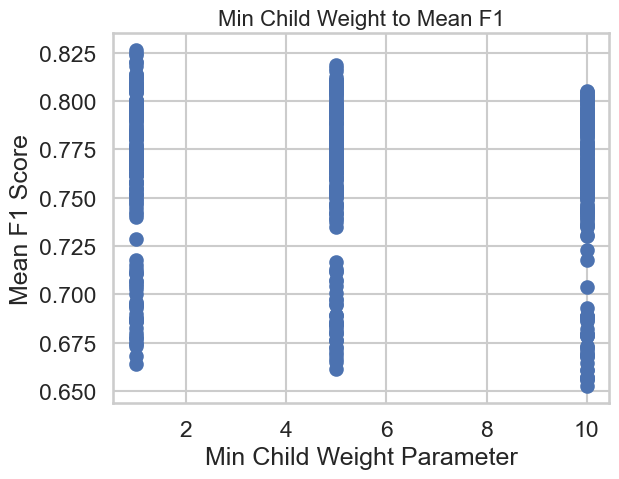

In [37]:
plt.scatter(df['min_child_weight'], df['cv_mean_f1'])
plt.title('Min Child Weight to Mean F1', fontsize=16)
plt.xlabel('Min Child Weight Parameter')
plt.ylabel('Mean F1 Score')

#### Gamma

Text(0, 0.5, 'Mean F1 Score')

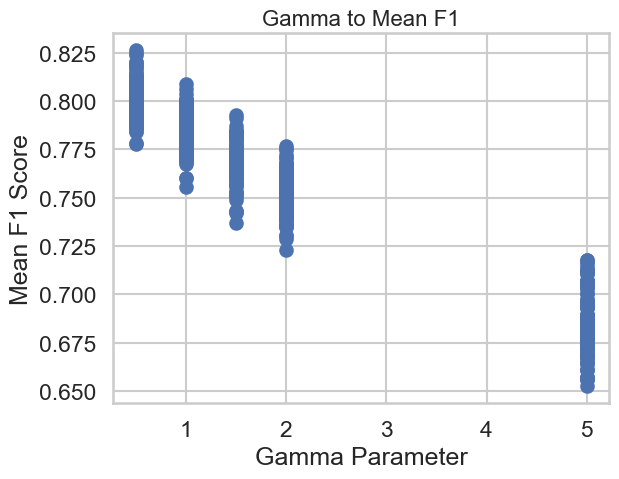

In [38]:
plt.scatter(df['gamma'], df['cv_mean_f1'])
plt.title('Gamma to Mean F1', fontsize=16)
plt.xlabel('Gamma Parameter')
plt.ylabel('Mean F1 Score')

#### Max Correlation Parameter

Text(0, 0.5, 'Mean F1 Score')

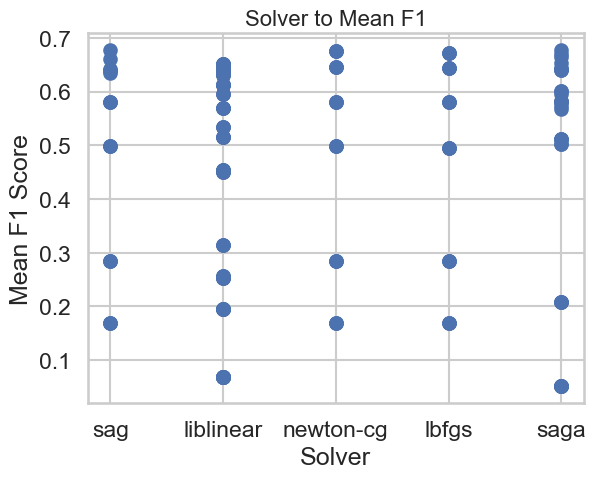

In [62]:
plt.scatter(df['solver'], df['cv_mean_f1'])
plt.title('Solver to Mean F1', fontsize=16)
plt.xlabel('Solver')
plt.ylabel('Mean F1 Score')

#### Max Iteration

Text(0, 0.5, 'Mean F1')

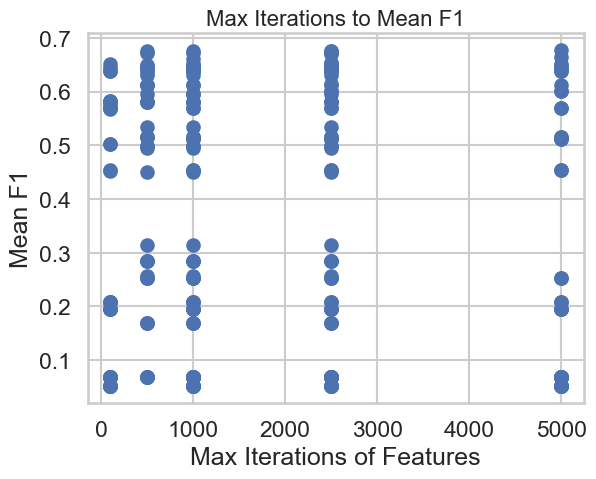

In [52]:
plt.scatter(df['max_iter'], df['cv_mean_f1'])
plt.title('Max Iterations to Mean F1', fontsize=16)
plt.xlabel('Max Iterations of Features')
plt.ylabel('Mean F1')

# 4 - Conclusion

In [ ]:
model_params = { 
    'penalty': 'l2',
    'C' : 10,
    'solver': 'newton-cg',
    'max_iter'  : 1000
}